## Import des librairies

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.metrics import mean_absolute_error

## Récupération des données

In [7]:
X_test = pd.read_csv('X_test.csv')
X_train = pd.read_csv('X_train.csv')
Y_train = pd.read_csv('Y_train.csv')

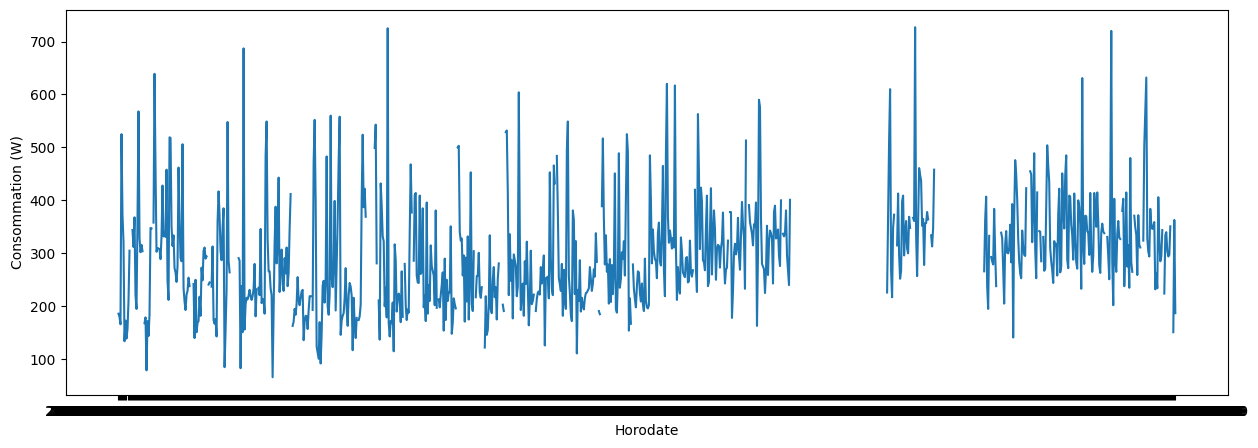

In [36]:
X = X_train['Horodate']
Y_holed = X_train['holed_1000'] # ont peut mettre 500 aussi
plt.figure(figsize=(15,5))
plt.plot(X, Y_holed)
plt.xlabel("Horodate")
plt.ylabel("Consommation (W)")
plt.show()

## Benchmark :

Pour ce challenge, nous avons utilisé un benchmark basique consistant à faire de l’interpolation linéaire sur les données manquantes.
Globalement, cette méthode remplit les valeurs manquantes par les valeurs prises par la fonction affine passant par le précédent point connu et le point connu suivant.
Pour plus de détails, se référer à cet article : https://fr.wikipedia.org/wiki/Interpolation_lin%C3%A9aire

In [19]:
def fill_nan_with_interpolation(column):
    col = column.copy()
    col = col.interpolate(method='linear', limit_direction='both')
    return col

## Application benchmark

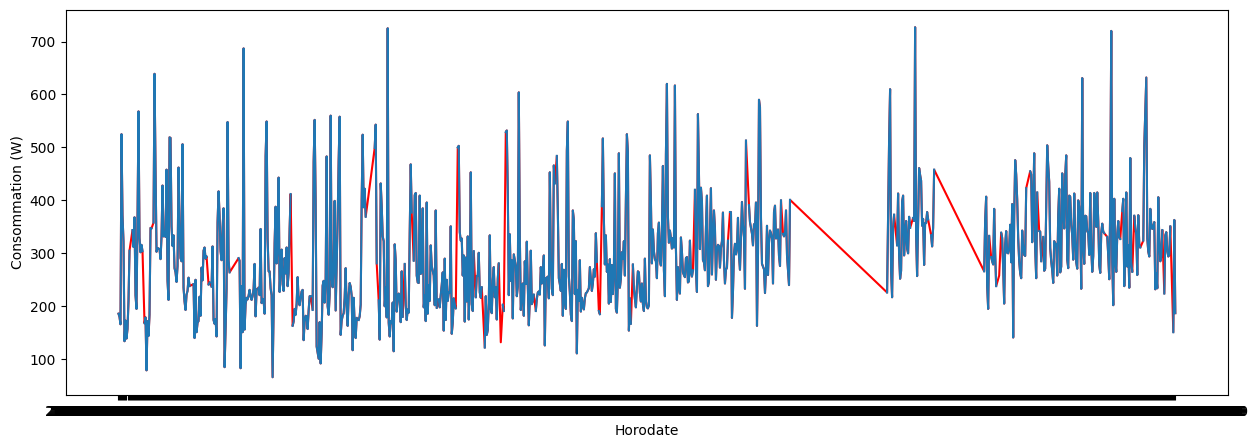

In [37]:
Benchmark_Y_holed = fill_nan_with_interpolation(Y_holed)

plt.figure(figsize=(15,5))
plt.plot(X, Benchmark_Y_holed, 'r')
plt.plot(X, Y_holed)
plt.xlabel("Horodate")
plt.ylabel("Consommation (W)")
plt.show()

## Mean absolute error

In [55]:
a = np.asarray(Y_holed)
b = np.asarray(Benchmark_Y_holed)
mask = ~np.isnan(a) & ~np.isnan(b)
mae = mean_absolute_error(a[mask],b[mask])

print("MSE: ", mae)

MSE:  0.0
